## Escuela Politécnica Nacional  
### Nombre: Nathaly Paola Bravo Jami 
### Curso: GR1CC
### Tarea 05

### 1 . Sea $f(x) = -x^3 - cos x$ y $p_0 = -1$. Utilice el método de Newton y de la Secante para encontrar $p_2$. ¿Se podría usar $p_0 = 0$?

Definir la función y su derivada 

In [1]:
import math
import numpy as np 
from scipy.optimize import newton, bisect
import matplotlib.pyplot as plt

In [2]:
def f(x):
    return -x**3 - math.cos(x)

In [3]:
def fprime(x):
    return -3*x**2 + math.sin(x)

Calcular la raíz con el punto estimado $p_0 = -1$ para encontrar $p_2$

* Newton

In [4]:
raiz = newton(f, -1, fprime, maxiter = 2, tol=1e-1)    
float(raiz)

-0.8656841631760818

In [ ]:
#raiz = newton(f, 0, fprime)     Problema encontrado 

* Secante

In [6]:
raiz = newton(f, -1, maxiter = 2, tol=1e-1)
float(raiz)

-0.8672398597656004

In [7]:
raiz = newton(f, 0)
float(raiz)

-4.998000183473029e-09

Como en el método de newton la derivada aparece en el denominador y se cumple que  $f'(0) = 0$, no es posible tomar $p_0 = 0$, porque se produciría una division entre cero. En cambio con el método de la secante si permite utilizar ese valor inicial.

# 2. Encuentre soluciones precisas dentro de $10^{-4}$ para los siguientes problemas.

Definimos una función que encuentra todas las raíces dentro de un intervalo

In [11]:
def metodo_newton(f, fprime,a,b, tolerancia):
    raices_newton = []
    estimaciones = np.linspace(a, b, 30)
    for valor in estimaciones:
        try:
            raiz_newton = newton(f, valor, fprime, tol=tolerancia)
            raiz_newton = round(raiz_newton, 4)
            if raiz_newton not in raices_newton and (a <= raiz_newton <= b):
                raices_newton.append(raiz_newton)
                print(f'Raíz cerca de {valor}: {raiz_newton}')
                continue
        except RuntimeError:
            pass

### a) $$x^3-2x^2-5 = 0,     [1,4]$$


Definió el intervalo para buscar las raíces y la función junto con su derivada

In [12]:
a,b = 1,4
def f(x):
    return x**3 - 2*x**2 - 5
def fprime(x):
    return 3*x**2 - 4*x

In [13]:
metodo_newton(f, fprime,a,b, 1e-4)

Raíz cerca de 1.0: 2.6906


### b) $$x^3+3x^2-1 = 0,     [-3,-2]$$

In [14]:
a,b = -3,-2
def f(x):
    return x**3 +3*x**2 - 1
def fprime(x):
    return 3*x**2 + 6*x

In [16]:
metodo_newton(f, fprime,a,b, 1e-4)

Raíz cerca de -3.0: -2.8794


### c) $$x-cosx = 0,     [0,\pi/2]$$

In [17]:
a,b = 0,math.pi/2
def f(x):
    return x-math.cos(x)
def fprime(x):
    return 1 + math.sin(x)

In [18]:
metodo_newton(f, fprime,a,b, 1e-4)

Raíz cerca de 0.0: 0.7391


### d) $$x-0.8-0.2senx = 0,     [0,\pi/2]$$

In [19]:
a,b = 0,math.pi/2
def f(x):
    return x-0.8-0.2*math.sin(x)
def fprime(x):
    return 1 - 0.2*math.cos(x)

In [20]:
metodo_newton(f, fprime,a,b, 1e-4)

Raíz cerca de 0.0: 0.9643


# 3. Use los 2 métodos en esta sección para encontrar las soluciones dentro de $10^{-5}$ para los siguientes problemas

Definimos adicionalmente la función que encuentre las raíces dentro de un intervalo pero ahora con la secante

In [21]:
def metodo_secante(f,a,b, tolerancia):
    raices_newton = []
    estimaciones = np.linspace(a, b, 30)
    for valor in estimaciones:
        try:
            raiz_newton = newton(f, valor, tol=tolerancia)
            raiz_newton = round(raiz_newton, 4)
            if raiz_newton not in raices_newton and (a <= raiz_newton <= b):
                raices_newton.append(raiz_newton)
                print(f'Raíz cerca de {valor}: {raiz_newton}')
                continue
        except RuntimeError:
            pass

<!-- Y reescribimos el método de newton para ahora una solución dentro de $10^{-5}$ -->

### a) $3x - e^x = 0$ para $1\le x \le 2$

In [25]:
a,b = 1,2

In [26]:
def f(x):
    return 3*x - math.exp(x)
def fprime(x):
    return 3 - math.exp(x)

* Newton

In [27]:
metodo_newton(f, fprime,a,b, 1e-5)

Raíz cerca de 1.103448275862069: 1.5121


* Secante

In [28]:
metodo_secante(f,a,b, 1e-5)

Raíz cerca de 1.103448275862069: 1.1034
Raíz cerca de 1.1379310344827587: 1.5121


### b) $2x + 3cosx - e^x = 0$ para $1\le x\le 2$

In [29]:
def f(x):
    return 2*x + 3*math.cos(x) - math.exp(x)
def fprime(x):
    return 2 - 3*math.sin(x) - math.exp(x)

* Newton

In [30]:
metodo_newton(f, fprime,a,b, 1e-5)

Raíz cerca de 1.0: 1.2397


* Secante

In [31]:
metodo_secante(f,a,b, 1e-5)

Raíz cerca de 1.0: 1.2397


### 4. El polinomio de cuarto grado $$f(x) = 230x^4 + 18x^3 + 9x^2 - 221x - 9$$ tiene dos ceros reales, uno en $[-1, 0]$ y el otro en $[0,1]$. Intente aproximar estos ceros dentro de $10^{-6}$ con 

Definir la función y su derivada

In [32]:
def f(x):
    return 230*x**4 + 18*x**3 + 9*x**2 - 221*x - 9

def fprime(x):
    return 920*x**3 + 54*x**2 + 18*x - 221

#### a) El método de la secante (use los extremos como los puntos iniciales)

Definimos el intervalo

In [33]:
a,b = -1, 1 

In [35]:
metodo_secante(f,a,b, 10**-6)

Raíz cerca de -1.0: -0.0407
Raíz cerca de 0.6551724137931034: 0.9624


#### b) El método de Newton (use el punto medio como estimación inicial)

Definimos el punto medio

In [36]:
punto_medio = (a + b) / 2
punto_medio

0.0

In [37]:
raiz = newton(f, punto_medio, tol=10**-6)
float(raiz)

-0.04065928831548335

### 5. La función $f(x) = tan\pi x - 6$ tiene cero en $(\frac{1}{\pi})arcotangente 6 \approx 0.447431543$. sea $p_0 = 0$ y $p_1 = 0.48$ y use 10 iteraciones en cada uno de los siguientes métodos para aproximar esta raíz. ¿Cuál método es más eficaz y por qué?

Definir la función y su derivada

In [65]:
def f(x):
    return math.tan(np.pi * x) - 6

def fprime(x):
    return (math.pi) / (math.cos(math.pi * x))**2

#### a) **Método de bisección**

In [56]:
try:
    raiz = bisect(f, 0, 0.48, maxiter=10)
    float(raiz)
    
except RuntimeError as e:
    print(e)


Failed to converge after 10 iterations.


#### b) **Método de Newton**

In [57]:
try:
    raiz = newton(f, 0,fprime = fprime, maxiter=10)
    print(float(raiz))
except RuntimeError as e:
    print(e)

Failed to converge after 10 iterations, value is 13.655012218663435.


In [58]:
try:
    raiz = newton(f, 0.48,fprime = fprime, maxiter=10)
    print(float(raiz))
except RuntimeError as e:
    print(e)

0.4474315432887487


#### c) **Método de la secante**

In [59]:
try:
    raiz = newton(f, x0=0, maxiter=10)
    print(float(raiz))
except RuntimeError as e:
    print(e)

Failed to converge after 10 iterations, value is 19771.74325658519.


In [60]:
try:
    raiz = newton(f, x0=0.48, maxiter=10)
    print(float(raiz))
except RuntimeError as e:
    print(e)

0.44743154328893403


Los métodos de Newton y de la secante son los más eficientes, debido a que ambos consiguen converger siempre que se cumplan las condiciones necesarias $p = 0.48$

### 6. La función descrita por $$f(x) = ln(x^2 + 1) - e^{0.4x} cos\pi x $$ tiene un número infinito de ceros.

Definir la función

In [67]:
def f(x):
    return np.log(x**2 +1) - np.exp(0.4*x) * np.cos(np.pi* x)

In [69]:
raíz = newton(f, 1, tol=1e-6)
float(raíz)

-0.43414304730450665

### b) Determine, dentro de $10^{-6}$, los cuatro ceros positivos más pequeños.

In [70]:
a,b=0, 4

In [71]:
metodo_secante(f,a,b, 1e-6)

Raíz cerca de 0.0: 0.4507
Raíz cerca de 1.2413793103448276: 2.2383
Raíz cerca de 1.3793103448275863: 1.7447
Raíz cerca de 3.310344827586207: 3.709


#### c) Determine una aproximación inicial razonable para encontrar el enésimo cero positivo más pequeño de f. [Sugerencia: Dibuje una gráfica aproximada de 𝑓.]

Gráfica de  la función

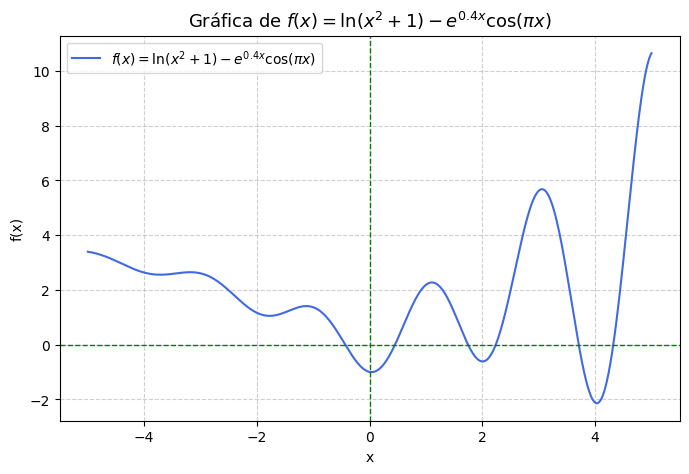

In [75]:
x = np.linspace(-5, 5, 1000)
y = f(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r"$f(x) = \ln(x^2 + 1) - e^{0.4x}\cos(\pi x)$", color="royalblue")
plt.axhline(0, color="green", linewidth=1, linestyle="--")  
plt.axvline(0, color="green", linewidth=1, linestyle="--")  

plt.title("Gráfica de $f(x) = \\ln(x^2 + 1) - e^{0.4x}\\cos(\\pi x)$", fontsize=13)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [76]:
def raiz_n(n):
    try:
        r = newton(f, x0=n-1+0.3, x1=n-1+0.07, tol=1e-6)
        return r
    except RuntimeError:
        return None

In [77]:
print(raiz_n(6))

5.6199353308973485


#### d) Use la parte c) para determinar, dentro de $10^{-6}$, el vigesimoquinto cero positivo más pequeño de f.

In [43]:
print(raiz_n(25))

24.499887047441387


### 7.La función $𝑓(𝑥)=𝑥^{\frac{1}{3}}$ tiene raíz en 𝑥 =0.Usando el punto de inicio de 𝑥 =1 y 𝑝0 =5, 𝑝1 =0.5 para el método de secante, compare los resultados de los métodos de la secante y de Newton

Definir la función y su derivada

In [78]:
def f(x):
    return np.cbrt(x)

def fprime(x):
    return (1/3) * x**(-2/3)

In [79]:
try:
    raiz = newton(f, x0=5, x1= 0.5)
    print(f'La raiz con el metodo de la secante es {raiz}')
except RuntimeError as e:
    print(e)

try:
    raiz = newton(f, x0=5, x1=0.5, fprime=fprime)
    print(f'La raiz con el metodo de Newton es {raiz}')
except RuntimeError as e:
    print(e)

Failed to converge after 50 iterations, value is 0.15125956067017968.
Failed to converge after 50 iterations, value is nan.


C:\Users\Nathaly\AppData\Local\Temp\ipykernel_11848\3331243702.py:5: RuntimeWarning: invalid value encountered in scalar power
  return (1/3) * x**(-2/3)


Debido al dominio de la función, ninguno de los dos métodos logra converger; sin embargo, el único que proporciona un resultado es el método de la secante